In [ ]:
# time series

In [ ]:
pip install pmdarima

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import pmdarima as pm

In [ ]:
airline = pd.read_csv('/content/AirPassengers.csv', index_col='Month',parse_dates=True)
# print the first five rows of the dataset
airline.head()

,#Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121


In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose
# ETS Decomposition
result = seasonal_decompose(airline['#Passengers'],model='multiplicative')

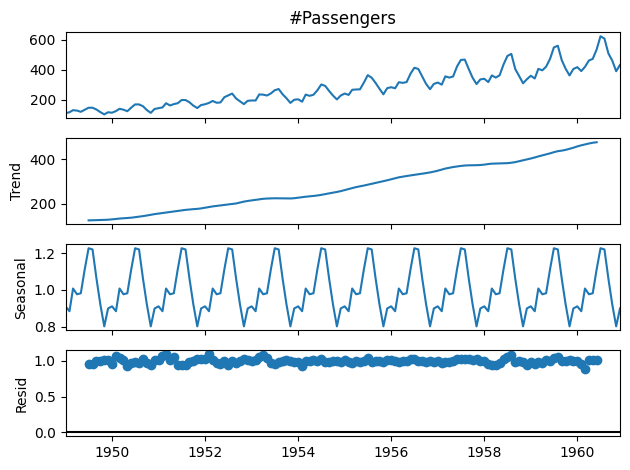

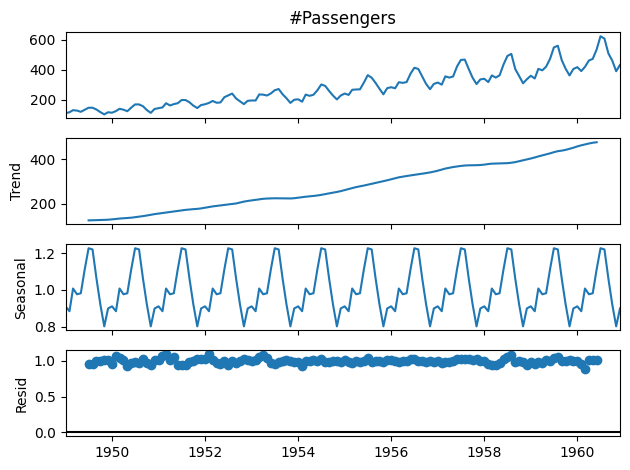

In [ ]:
result.plot()

In [ ]:
# fit auto arima function to AirPassengers dataset
from pmdarima import auto_arima
stepwise_fit = auto_arima(airline['#Passengers'],start_q=1,max_p =3,max_q=3,m=12,
                          start_P=0,seasonal=True,
                          d=None,D=1,trace=True,
                          error_action='ignore',# we don't want to know if , an order does not work
                          suppress_warnings=True)# set to stepwise
                          #To print the summary
stepwise_fit.summary()

Performing stepwise search to minimize aic
 ARIMA(2,1,1)(0,1,1)[12]             : AIC=1018.359, Time=0.82 sec
 ARIMA(0,1,0)(0,1,0)[12]             : AIC=1031.508, Time=0.04 sec
 ARIMA(1,1,0)(1,1,0)[12]             : AIC=1020.393, Time=0.14 sec
 ARIMA(0,1,1)(0,1,1)[12]             : AIC=1021.003, Time=0.22 sec
 ARIMA(2,1,1)(0,1,0)[12]             : AIC=1017.847, Time=0.30 sec
 ARIMA(2,1,1)(1,1,0)[12]             : AIC=1017.914, Time=0.77 sec
 ARIMA(2,1,1)(1,1,1)[12]             : AIC=1018.248, Time=1.52 sec
 ARIMA(1,1,1)(0,1,0)[12]             : AIC=1022.393, Time=0.11 sec
 ARIMA(2,1,0)(0,1,0)[12]             : AIC=1022.393, Time=0.08 sec
 ARIMA(3,1,1)(0,1,0)[12]             : AIC=1019.084, Time=0.30 sec
 ARIMA(2,1,2)(0,1,0)[12]             : AIC=1019.290, Time=0.30 sec
 ARIMA(1,1,0)(0,1,0)[12]             : AIC=1020.393, Time=0.06 sec
 ARIMA(1,1,2)(0,1,0)[12]             : AIC=1024.160, Time=0.19 sec
 ARIMA(3,1,0)(0,1,0)[12]             : AIC=1023.666, Time=0.11 sec
 ARIMA(3,1,2)(0,1,0

<class 'statsmodels.iolib.summary.Summary'>
"""
                                      SARIMAX Results                                      
===========================================================================================
Dep. Variable:                                   y   No. Observations:                  144
Model:             SARIMAX(2, 1, 1)x(0, 1, [], 12)   Log Likelihood                -504.923
Date:                             Tue, 28 Apr 2026   AIC                           1017.847
Time:                                     10:12:47   BIC                           1029.348
Sample:                                 01-01-1949   HQIC                          1022.520
                                      - 12-01-1960                                         
Covariance Type:                               opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.5960      0.085      6.987      0.000       0.429       0.763
ar.L2          0.2143      0.091      2.343      0.019       0.035       0.394
ma.L1         -0.9819      0.038    -25.602      0.000      -1.057      -0.907
sigma2       129.3133     14.556      8.884      0.000     100.783     157.843
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):                 7.68
Prob(Q):                              0.98   Prob(JB):                         0.02
Heteroskedasticity (H):               2.33   Skew:                            -0.01
Prob(H) (two-sided):                  0.01   Kurtosis:                         4.19
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [ ]:
# displaying first 10 rows
ts = airline['#Passengers']
ts.head(10)

,#Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121
1949-06-01,135
1949-07-01,148
1949-08-01,148
1949-09-01,136


In [ ]:
ts['1949-01-01']

np.int64(112)

In [ ]:
# specify the entire range:
ts['1949-01-01':'1949-05-01']

,#Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121


In [ ]:
# use'{}if one of the indices is at ends;
ts[:'1949-05-01']

,#Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121


In [ ]:
ts['1949']

,#Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121
1949-06-01,135
1949-07-01,148
1949-08-01,148
1949-09-01,136


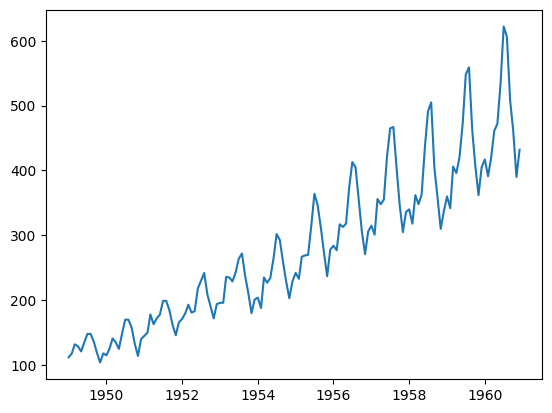

In [ ]:
plt.plot(ts)

In [ ]:
# calculate moving average and standard deviation
rolmean = ts.rolling(window=10).mean()
rolstd = ts.rolling(window=10).std()

In [ ]:
from statsmodels.tsa.stattools import adfuller
def test_stationarity(timeseries,m,s):
    # plot rolling statistics:
    plt.figure(figsize=(15,5))
    plt.plot(timeseries,color='blue',label='Original')
    plt.plot(rolmean,color='red',label='Rolling Mean')
    plt.plot(rolstd,color='black',label='Rolling Std')
    plt.legend(loc='best')
    plt.title('Rolling Mean & Standard Deviation')
    plt.show()
    # Perform Dickey-Fuller test:
    print('Dickey-Fuller Test Results:')
    dftest = adfuller(timeseries,autolag='AIC')
    dfoutput = pd.Series(dftest[0:4],index=['Test Statistic','p-value','#Lags Used','Number of Observations Used'])
    for key,value in dftest[4].items():
      dfoutput['Critical Value(%s)'%key] = value
    print(dfoutput)

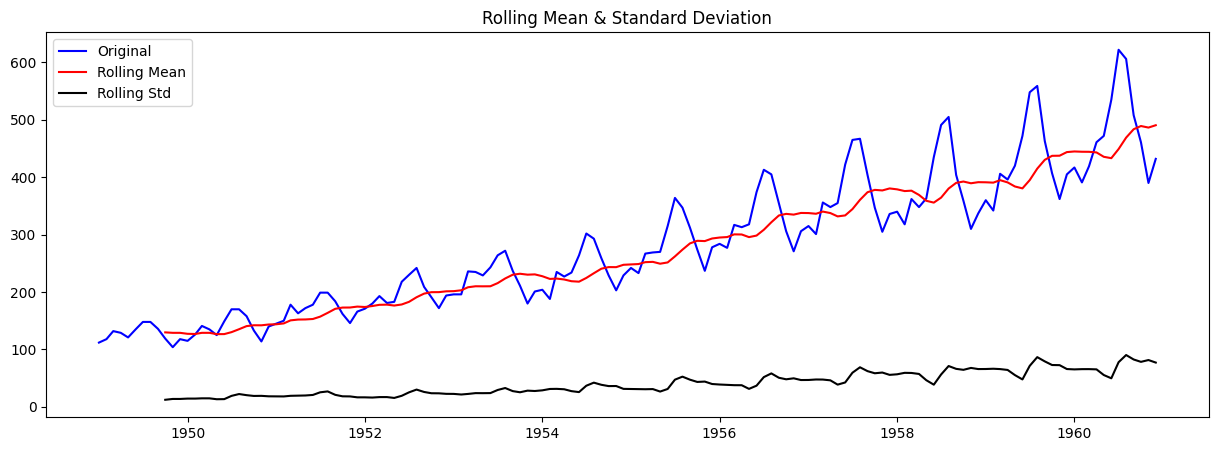

Dickey-Fuller Test Results:
Test Statistic                   0.815369
p-value                          0.991880
#Lags Used                      13.000000
Number of Observations Used    130.000000
Critical Value(1%)              -3.481682
Critical Value(5%)              -2.884042
Critical Value(10%)             -2.578770
dtype: float64


In [ ]:
test_stationarity(ts,rolmean,rolstd)

In [ ]:
# check with 1% critical value
0.815369< -3.481682

False

In [ ]:
# check with 5% critical value
0.815369<-2884042

False

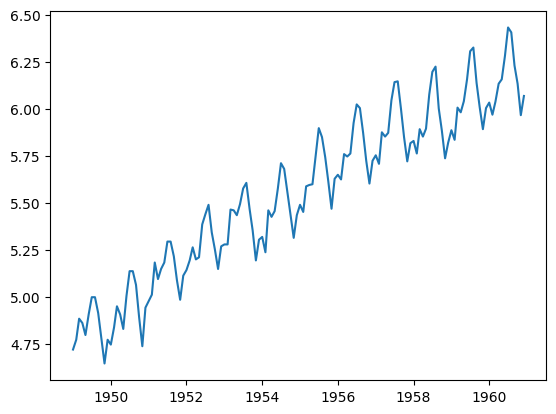

In [ ]:
import numpy as np
ts_log = np.log(ts)
plt.plot(ts_log)

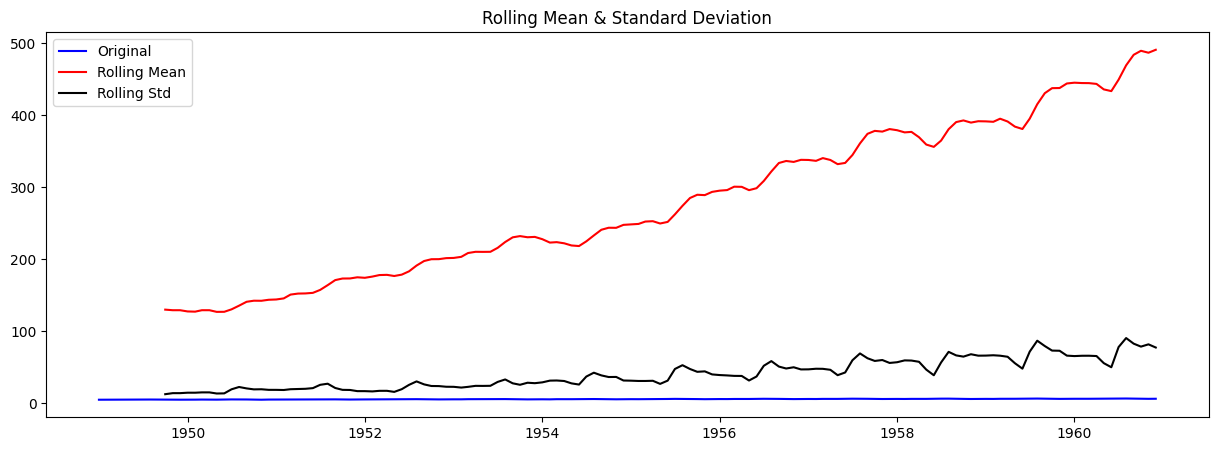

Dickey-Fuller Test Results:
Test Statistic                  -1.717017
p-value                          0.422367
#Lags Used                      13.000000
Number of Observations Used    130.000000
Critical Value(1%)              -3.481682
Critical Value(5%)              -2.884042
Critical Value(10%)             -2.578770
dtype: float64


In [ ]:
moving_avg = ts_log.rolling(window=12).mean()
moving_std = ts_log.rolling(window=12).std()
test_stationarity(ts_log,moving_avg,moving_std)

In [ ]:
-1.717017<-3.481662

False

In [ ]:
-1.717017<-2.684042

False

In [ ]:
# How subtract the rolling mean from the original series
ts_log_moving_avg_diff = ts_log - moving_avg
ts_log_moving_avg_diff.head(12)

,#Passengers
Month,
1949-01-01,NaN
1949-02-01,NaN
1949-03-01,NaN
1949-04-01,NaN
1949-05-01,NaN
1949-06-01,NaN
1949-07-01,NaN
1949-08-01,NaN
1949-09-01,NaN


In [ ]:
ts_log_moving_avg_diff.dropna(inplace=True)
ts_log_moving_avg_diff.head()

,#Passengers
Month,
1949-12-01,-0.065494
1950-01-01,-0.093449
1950-02-01,-0.007566
1950-03-01,0.099416
1950-04-01,0.052142


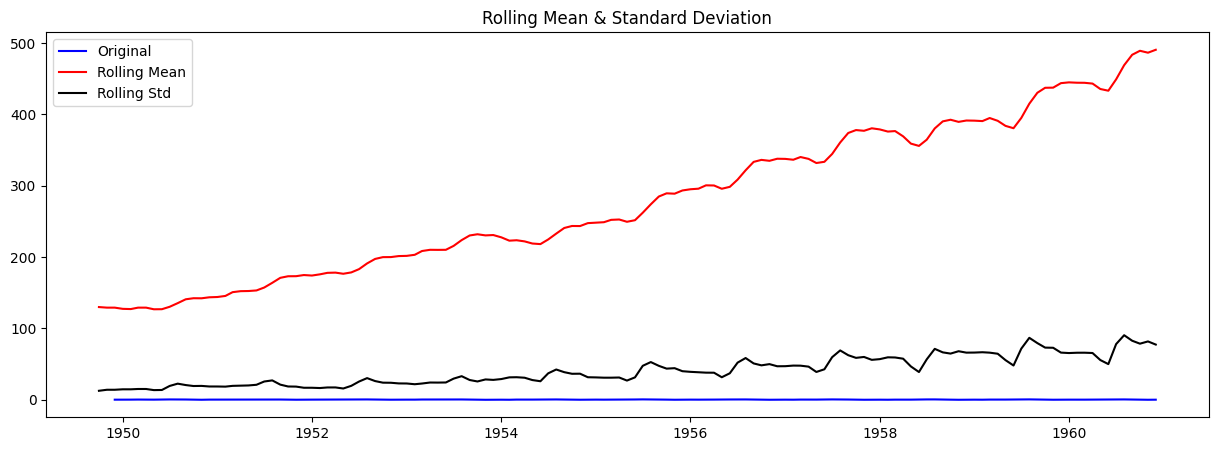

Dickey-Fuller Test Results:
Test Statistic                  -3.162908
p-value                          0.022235
#Lags Used                      13.000000
Number of Observations Used    119.000000
Critical Value(1%)              -3.486535
Critical Value(5%)              -2.886151
Critical Value(10%)             -2.579896
dtype: float64


In [ ]:
moving_avg = ts_log_moving_avg_diff.rolling(window=12).mean()
moving_std = ts_log_moving_avg_diff.rolling(window=12).std()
test_stationarity(ts_log_moving_avg_diff,moving_avg,moving_std)

In [ ]:
-3.162908<-3.486636

False

In [ ]:
-3.162905< -2.886151

True

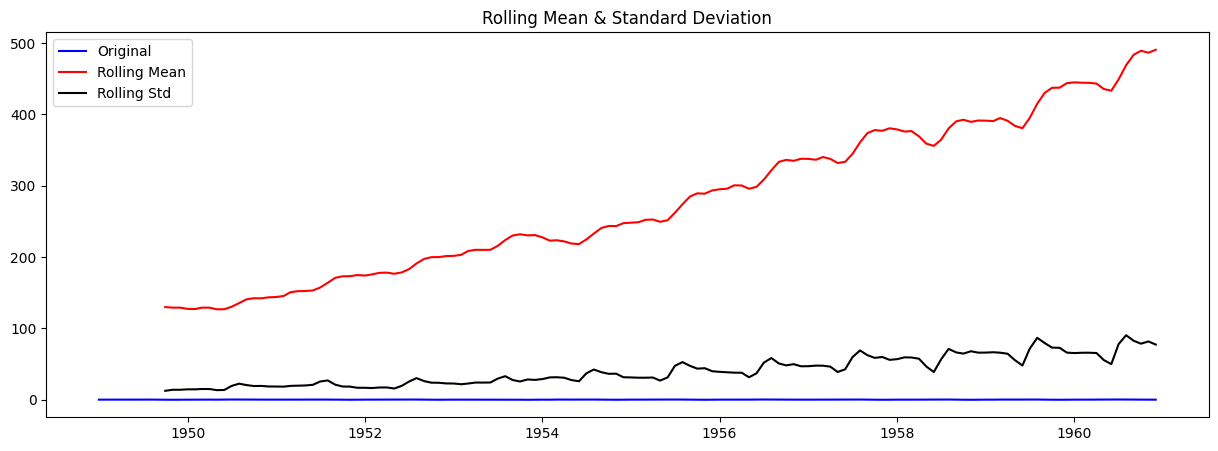

Dickey-Fuller Test Results:
Test Statistic                  -3.087696
p-value                          0.027477
#Lags Used                      13.000000
Number of Observations Used    130.000000
Critical Value(1%)              -3.481682
Critical Value(5%)              -2.884042
Critical Value(10%)             -2.578770
dtype: float64


In [ ]:
expvighted_avg = ts_log.ewm(halflife=2).mean()
moving_avg = expvighted_avg.rolling(window=12).mean()
moving_std = expvighted_avg.rolling(window=12).std()
ts_log_ewma_diff = ts_log - expvighted_avg
test_stationarity(ts_log_ewma_diff,moving_avg,moving_std)

In [ ]:
-3.601262 < -3.461682

True

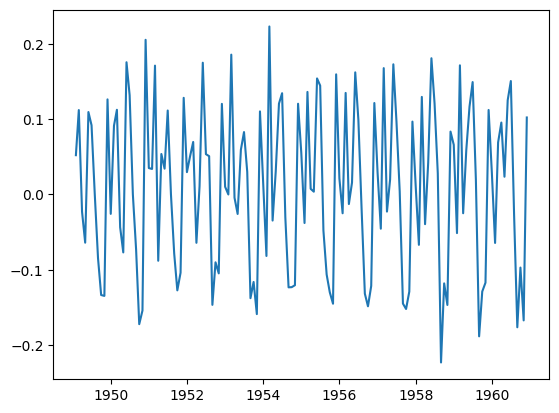

In [ ]:
# differencing
ts_log_diff = ts_log-ts_log.shift()
plt.plot(ts_log_diff)

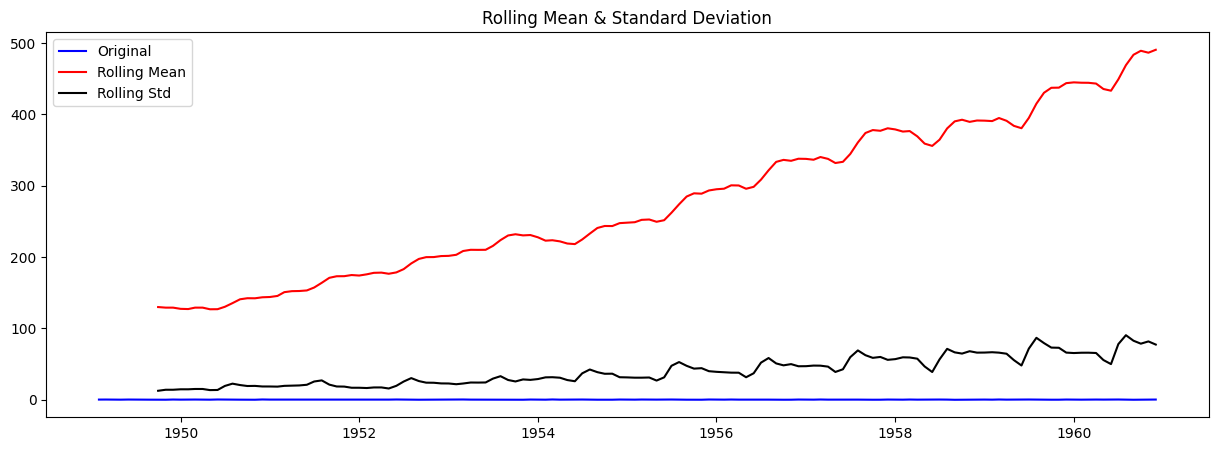

Dickey-Fuller Test Results:
Test Statistic                  -2.717131
p-value                          0.071121
#Lags Used                      14.000000
Number of Observations Used    128.000000
Critical Value(1%)              -3.482501
Critical Value(5%)              -2.884398
Critical Value(10%)             -2.578960
dtype: float64


In [ ]:
ts_log_diff.dropna(inplace=True)
moving_avg = ts_log_diff.rolling(window=12).mean()
moving_std = ts_log_diff.rolling(window=12).std()
test_stationarity(ts_log_diff,moving_avg,moving_std)

In [ ]:
# test Statistic < critical Value (1%)
-2.717141<-3.482601

False

In [ ]:
-2.717131<-2.884398

False

In [ ]:
-2.7171314<-2.578960

True

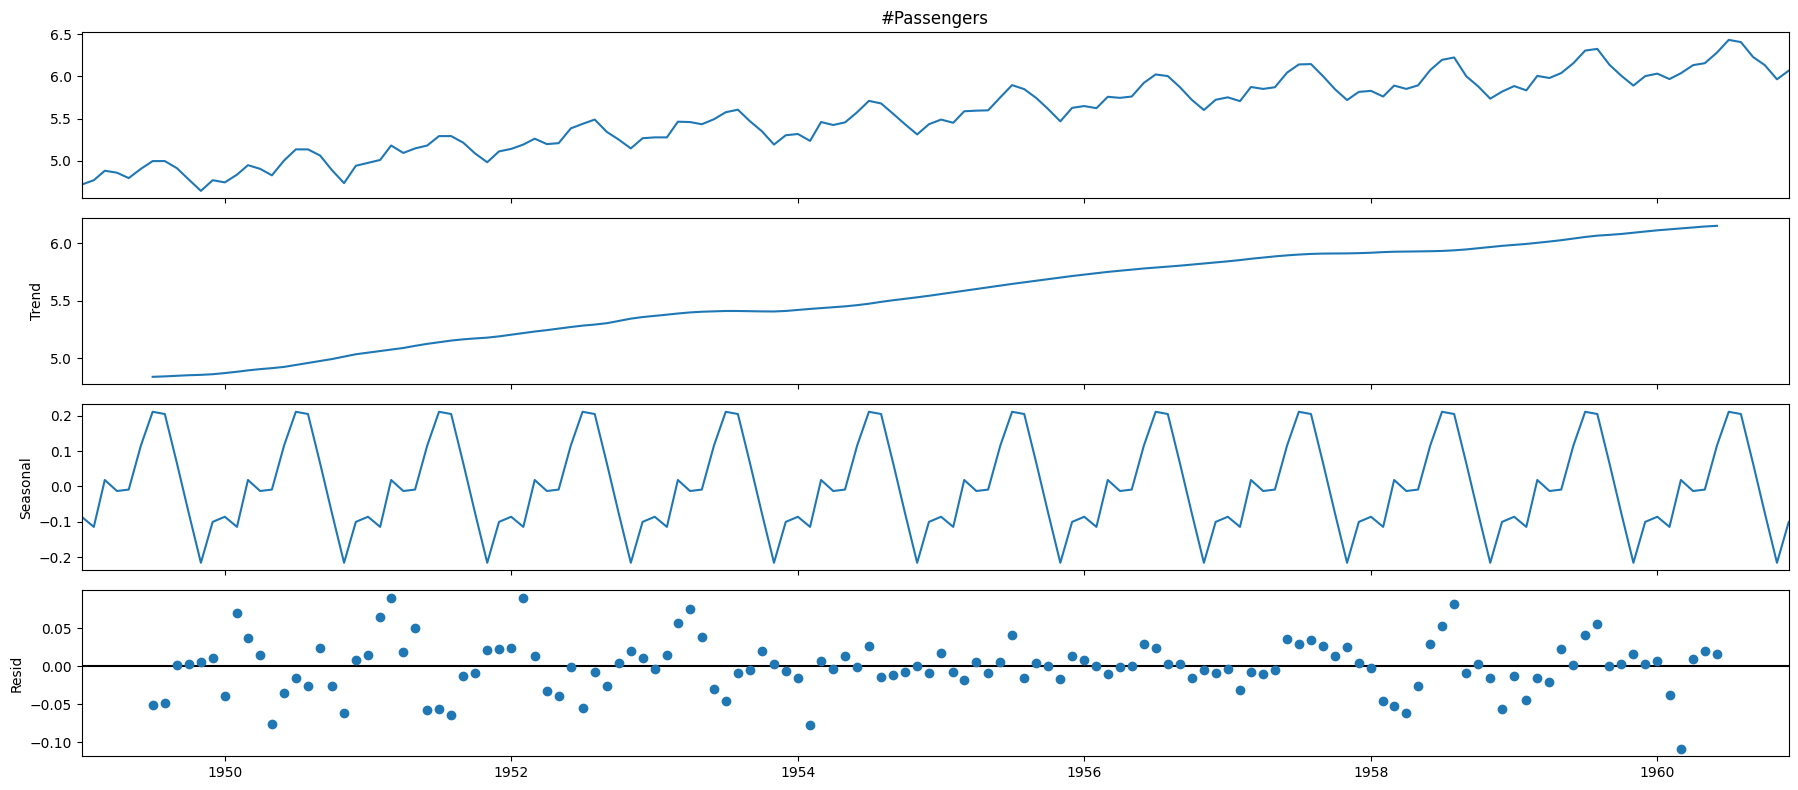

In [ ]:
from pylab import rcParams
import statsmodels.api as sm
rcParams['figure.figsize'] = 18,8
decomposition = seasonal_decompose(ts_log,model='additive')
fig = decomposition.plot()
plt.show()

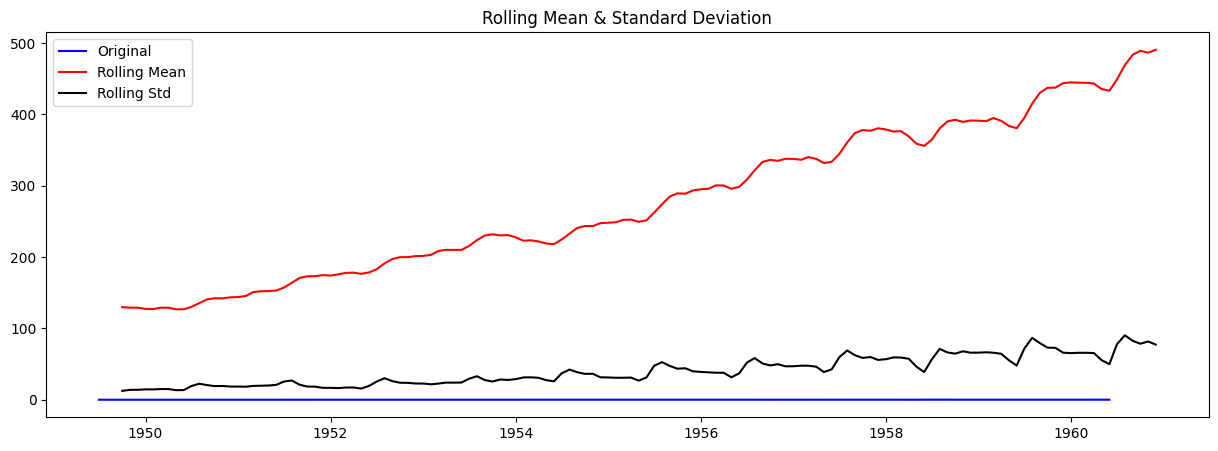

Dickey-Fuller Test Results:
Test Statistic                -6.332387e+00
p-value                        2.885059e-08
#Lags Used                     9.000000e+00
Number of Observations Used    1.220000e+02
Critical Value(1%)            -3.485122e+00
Critical Value(5%)            -2.885538e+00
Critical Value(10%)           -2.579569e+00
dtype: float64


In [ ]:
ts_log_decomose = decomposition.resid
ts_log_decomose.dropna(inplace=True)
moving_avg = ts_log_decomose.rolling(window=12).mean()
moving_std = ts_log_decomose.rolling(window=12).std()
test_stationarity(ts_log_decomose,moving_avg,moving_std)

In [ ]:
# ARIMA----- auto regressive intergrated moving averages
# ACF------ Autocorrelation Function(ACF)

In [ ]:
# ACF
from statsmodels.tsa.stattools import acf, pacf
lag_acf = acf(ts_log_diff,nlags=20)
lag_pacf = pacf(ts_log_diff,nlags=20,method='ols')

<Axes: >

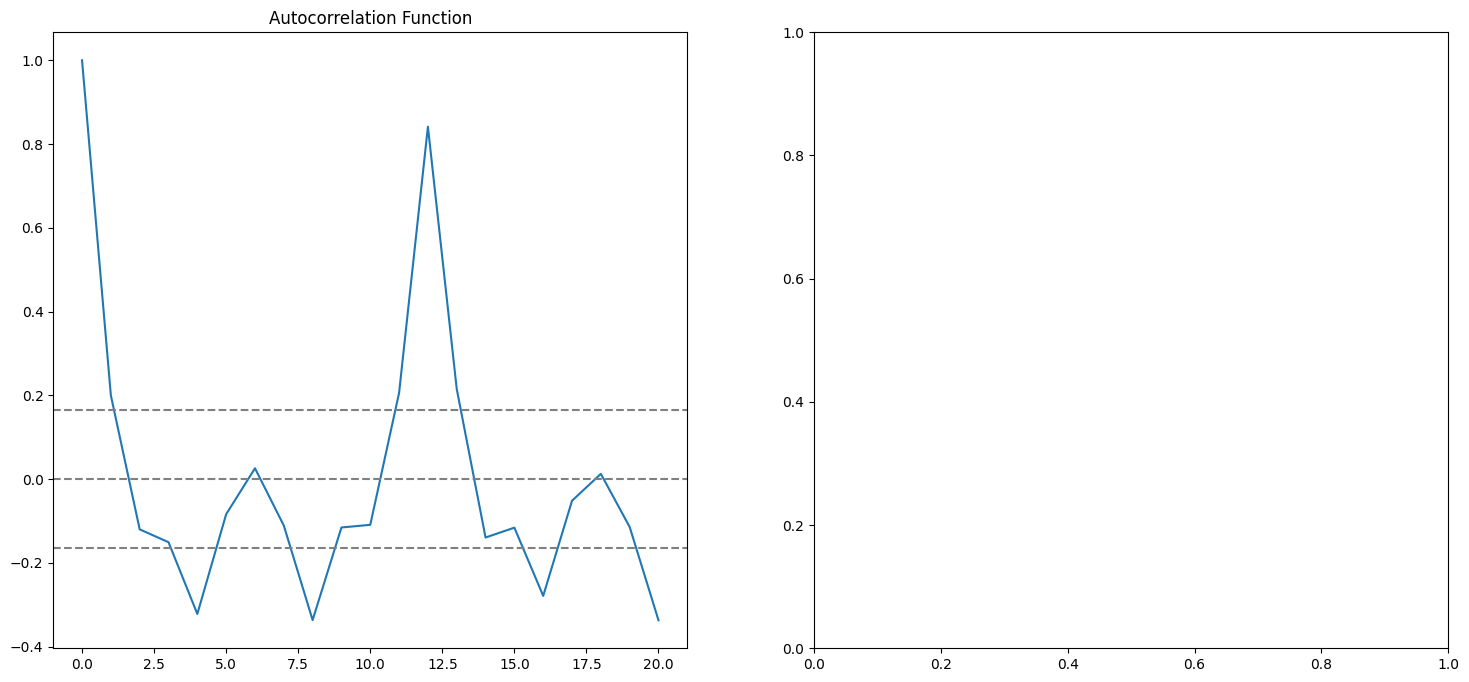

In [ ]:
from matplotlib.lines import lineStyles
plt.subplot(121)
plt.plot(lag_acf)
plt.axhline(y=0,linestyle='--',color='gray')
plt.axhline(y=-1.96/np.sqrt(len(ts_log_diff)),linestyle='--',color='gray')
plt.axhline(y=1.96/np.sqrt(len(ts_log_diff)),linestyle='--',color='gray')
plt.title('Autocorrelation Function')
# plot PACF:
plt.subplot(122)

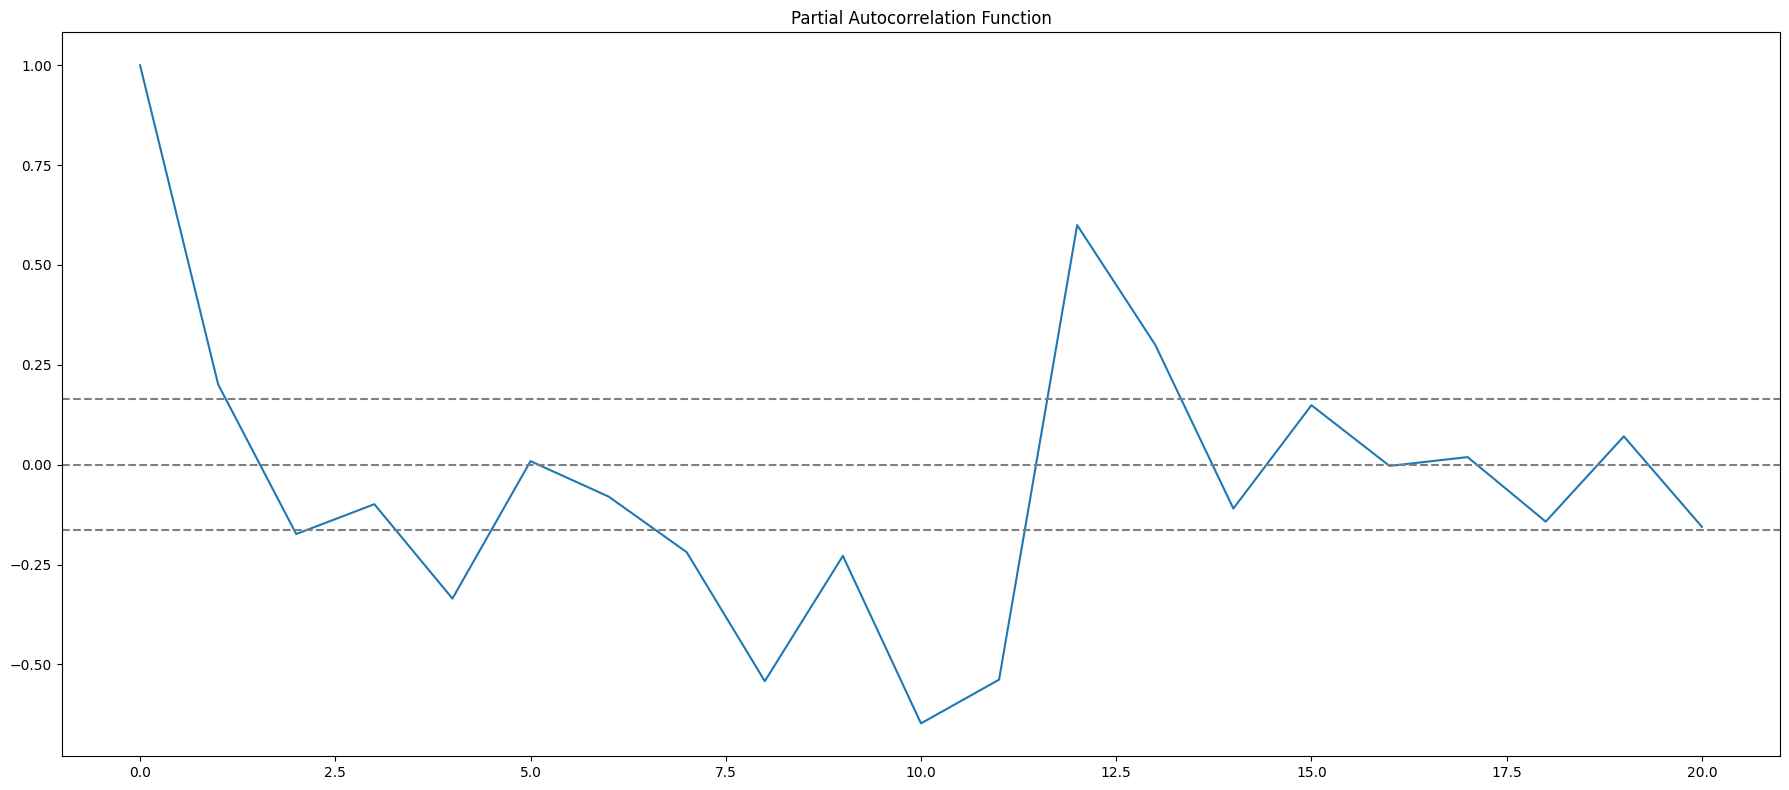

In [ ]:
plt.plot(lag_pacf)
plt.axhline(y=0,linestyle='--',color='gray')
plt.axhline(y=-1.96/np.sqrt(len(ts_log_diff)),linestyle='--',color='gray')
plt.axhline(y=1.96/np.sqrt(len(ts_log_diff)),linestyle='--',color='gray')
plt.title('Partial Autocorrelation Function')
plt.tight_layout()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


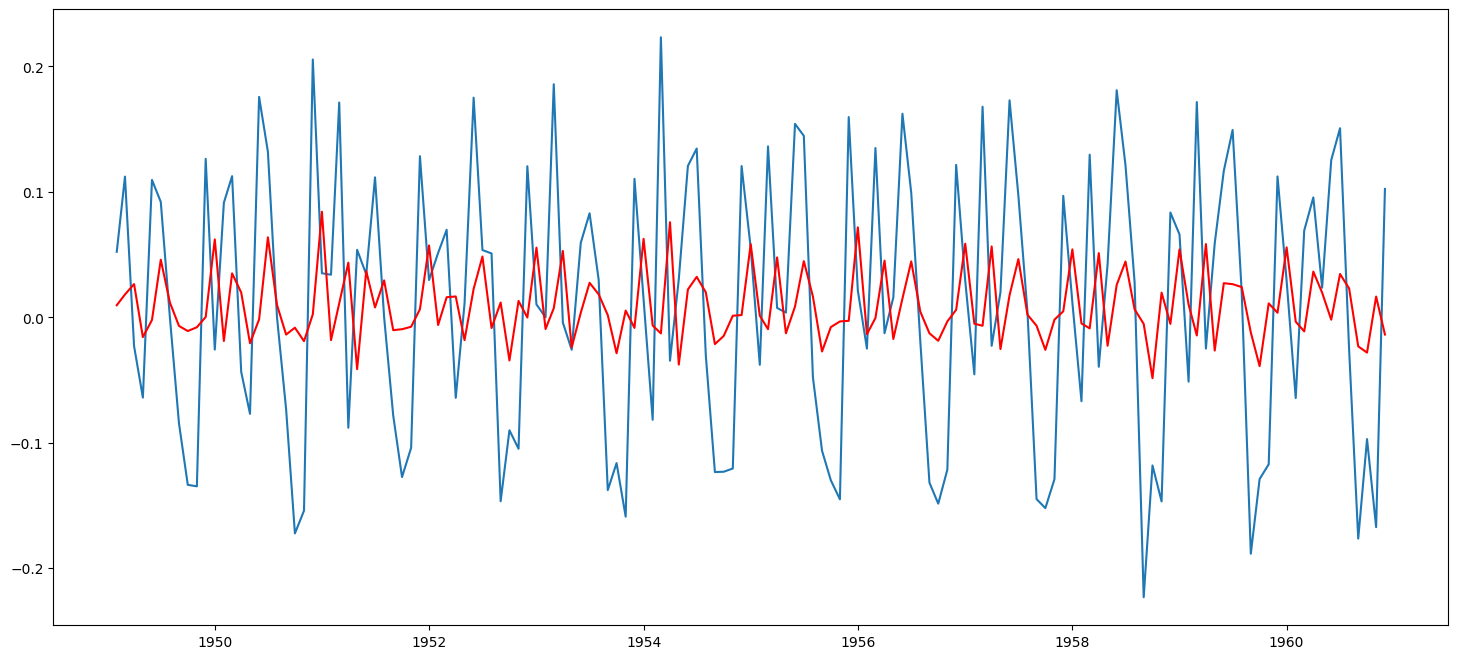

In [ ]:
from statsmodels.tsa.arima.model import ARIMA
# AR MODEL
model = ARIMA(ts_log_diff,order=(2,0,0))
results_AR = model.fit()
plt.plot(ts_log_diff)
plt.plot(results_AR.fittedvalues,color='red')




/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


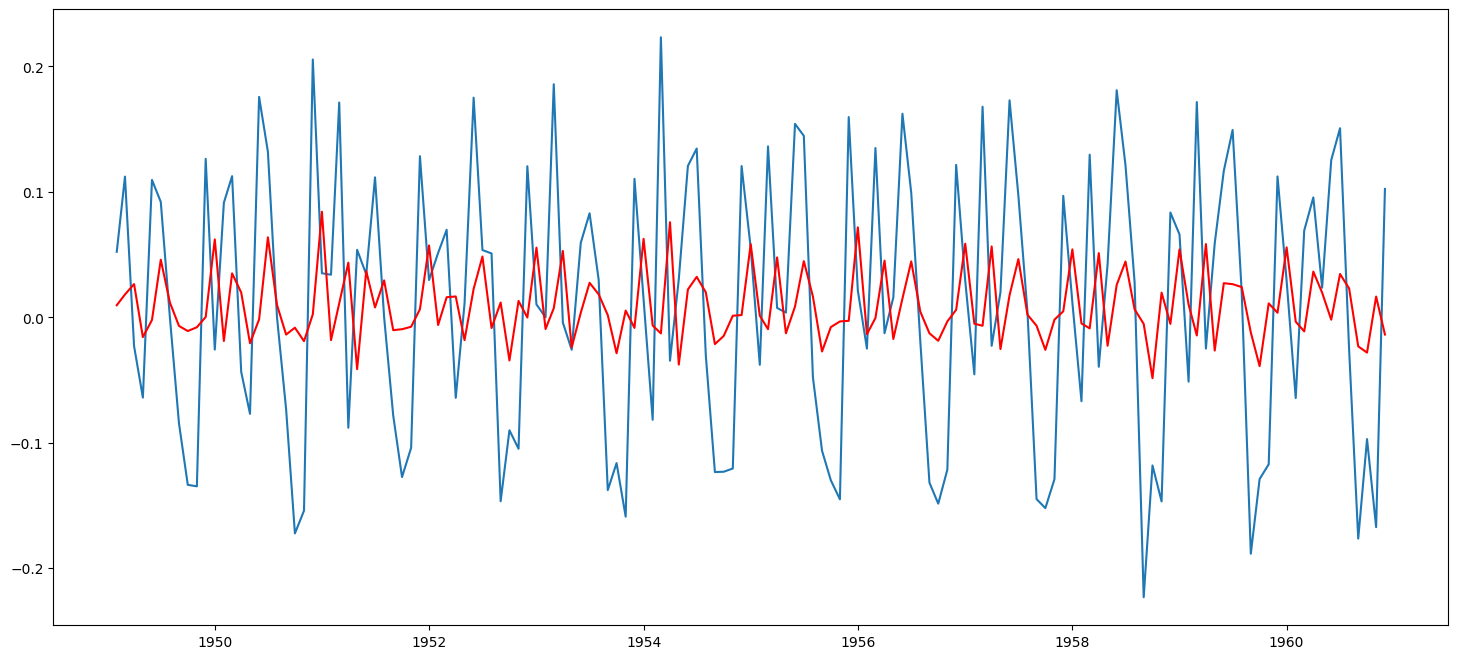

In [ ]:
model = ARIMA(ts_log_diff,order=(2,0,0))
results_AR = model.fit()
plt.plot(ts_log_diff)
plt.plot(results_AR.fittedvalues,color='red')

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Text(0.5, 1.0, 'RSS: 1.2170')

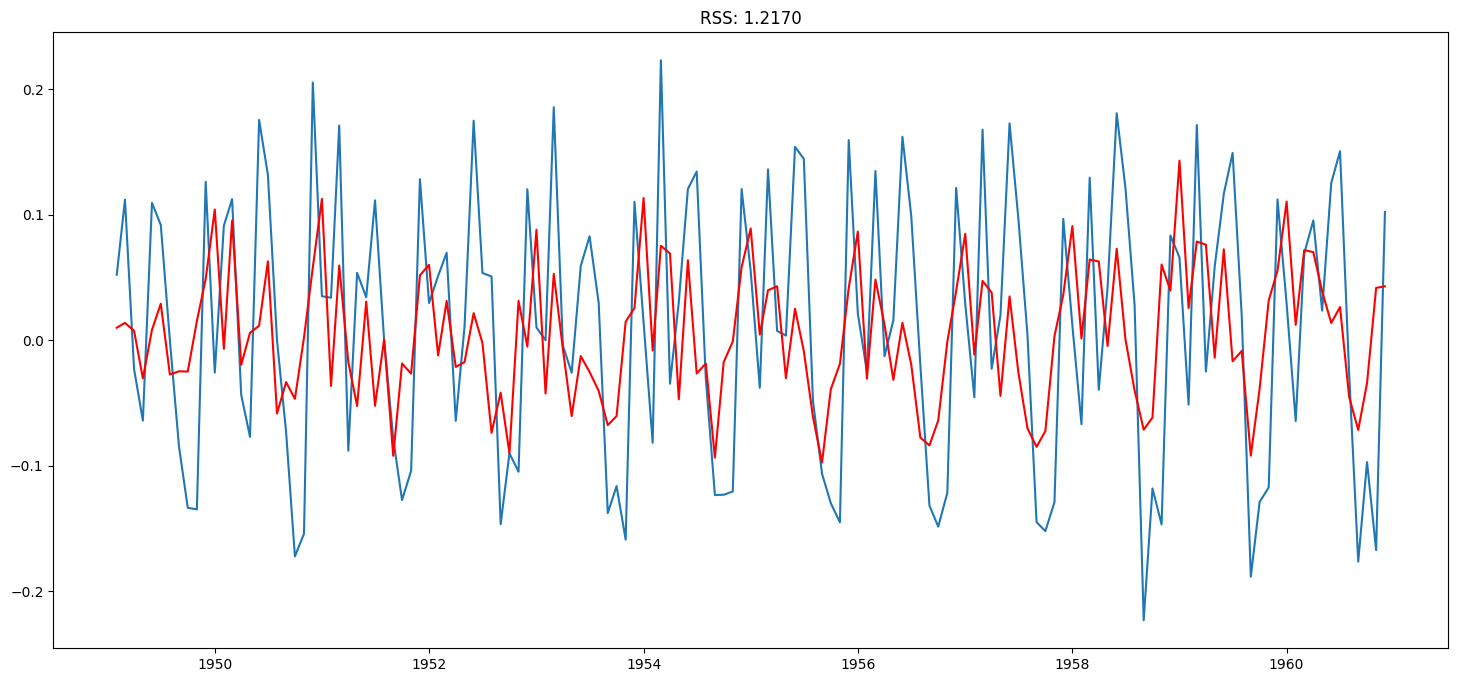

In [ ]:
model = ARIMA(ts_log_diff, order=(2, 0, 2))
results_ARIMA = model.fit()
plt.plot(ts_log_diff)
plt.plot(results_ARIMA.fittedvalues, color='red')
plt.title('RSS: %.4f'% sum((results_ARIMA.fittedvalues-ts_log_diff)**2))

In [ ]:
# summary of fit model
print(results_ARIMA.summary())

                               SARIMAX Results                                
Dep. Variable:            #Passengers   No. Observations:                  143
Model:                 ARIMA(2, 0, 2)   Log Likelihood                 137.616
Date:                Tue, 28 Apr 2026   AIC                           -263.231
Time:                        10:40:35   BIC                           -245.454
Sample:                    02-01-1949   HQIC                          -256.007
                         - 12-01-1960                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0100      0.001     11.771      0.000       0.008       0.012
ar.L1          0.2744      0.161      1.707      0.088      -0.041       0.589
ar.L2          0.1698      0.155      1.098      0.2

In [ ]:
predictions_ARIMA_diff= pd.Series(results_ARIMA.fittedvalues,copy=True)
print (predictions_ARIMA_diff.head())

Month
1949-02-01    0.010033
1949-03-01    0.013853
1949-04-01    0.007612
1949-05-01   -0.030328
1949-06-01    0.008316
dtype: float64


In [ ]:
predictions_ARIMA_diff_cumsum=predictions_ARIMA_diff.cumsum()
print(predictions_ARIMA_diff_cumsum.head())

Month
1949-02-01    0.010033
1949-03-01    0.023886
1949-04-01    0.031497
1949-05-01    0.001169
1949-06-01    0.009485
dtype: float64


In [ ]:
predictions_ARIMA_log= pd.Series(ts_log[0],index=ts_log.index)
predictions_ARIMA_log= predictions_ARIMA_log.add(predictions_ARIMA_diff_cumsum,fill_value=0)
predictions_ARIMA_log.head()

/tmp/ipykernel_2391/63222309.py:1: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  predictions_ARIMA_log= pd.Series(ts_log[0],index=ts_log.index)


,0
Month,
1949-01-01,4.718499
1949-02-01,4.728532
1949-03-01,4.742385
1949-04-01,4.749996
1949-05-01,4.719668


In [ ]:
predictions_ARIMA_diff_cumsum=predictions_ARIMA_diff.cumsum()
print(predictions_ARIMA_diff_cumsum.head())

Month
1949-02-01    0.010033
1949-03-01    0.023886
1949-04-01    0.031497
1949-05-01    0.001169
1949-06-01    0.009485
dtype: float64


Text(0.5, 1.0, 'RMSE: 179.0258')

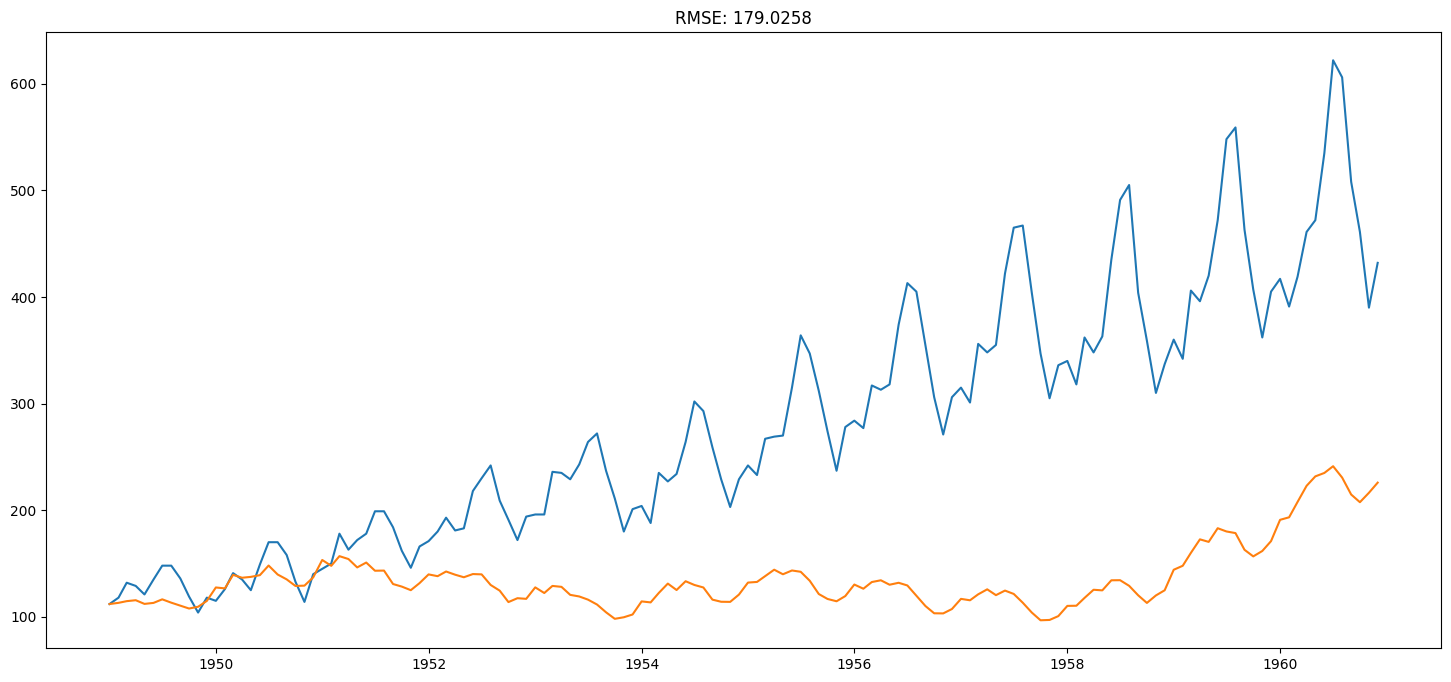

In [ ]:
predictions_ARIMA =np.exp(predictions_ARIMA_log)
plt.plot(ts)
plt.plot(predictions_ARIMA)
plt.title('RMSE: %.4f'%np.sqrt(sum((predictions_ARIMA-ts)**2)/len(ts)))